# <font color="#767676"> Dados dinâmicos</font>

    Como está distribuído o PIB nos últimos três quinquênios na Região Sul do Brasil divididos pelos estados?

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("https://raw.githubusercontent.com/afonsosr2/dataviz-graficos-composicao-relacionamento/master/dados/pib_br_2002_2020_estados.csv")
df.sample(5)

,ano,sigla_uf,regiao,pib,impostos_liquidos,va,va_agropecuaria,va_industria,va_servicos,va_adespss
492,2019,GO,Centro-Oeste,208672491708,23475570946,185196920768,21176310751,39177869333,91287240881,33555499807
43,2007,AM,Norte,43479773086,7550984241,35928788844,1209601586,15296869677,13293669774,6128647810
209,2002,PB,Nordeste,12747021186,1358801304,11388219880,755986580,2224280212,4837137437,3570815642
227,2020,PB,Nordeste,70292034110,7824002200,62468031908,2823160239,10000792872,29024383962,20619694846
303,2020,BA,Nordeste,305320812691,37094030606,268226782074,28006935845,59491629932,122722534188,58005682122


In [23]:
anos = [ano for ano in range(2010,2021, 5)]
print(f"Anos avaliados {anos}")

Anos avaliados [2010, 2015, 2020]


In [56]:
print(f"{'Creating the DataFrame of the Query':_^100}")
df_sul = df.query("regiao =='Sul' and ano in @anos")[["ano", "sigla_uf", "pib"]]
df_sul["pib_bi"] = (df_sul["pib"] / 1e9).round(2)
df_sul.drop(columns="pib", inplace=True)
df_sul.reset_index(drop=True, inplace=True)
display(df_sul)

print(f"{'Creating the Cross-Table':_^100}")
crosst_sul = pd.crosstab(
    index=df_sul.ano,
    columns=df_sul.sigla_uf,
    values=df_sul.pib_bi,
    aggfunc="sum",
    normalize="index", # => Normalizando (%) de acordo com o Ano
)
display(crosst_sul)

________________________________Creating the DataFrame of the Query_________________________________


,ano,sigla_uf,pib_bi
0,2010,PR,225.21
1,2015,PR,376.96
2,2020,PR,487.93
3,2010,SC,153.73
4,2015,SC,249.08
5,2020,SC,349.28
6,2010,RS,241.25
7,2015,RS,381.99
8,2020,RS,470.94


______________________________________Creating the Cross-Table______________________________________


sigla_uf,PR,RS,SC
ano,,,
2010,0.363131,0.388994,0.247876
2015,0.373957,0.378947,0.247096
2020,0.372992,0.360005,0.267003


**Visualizando os Dados**


In [90]:
crosst_sul.reset_index(inplace=True)

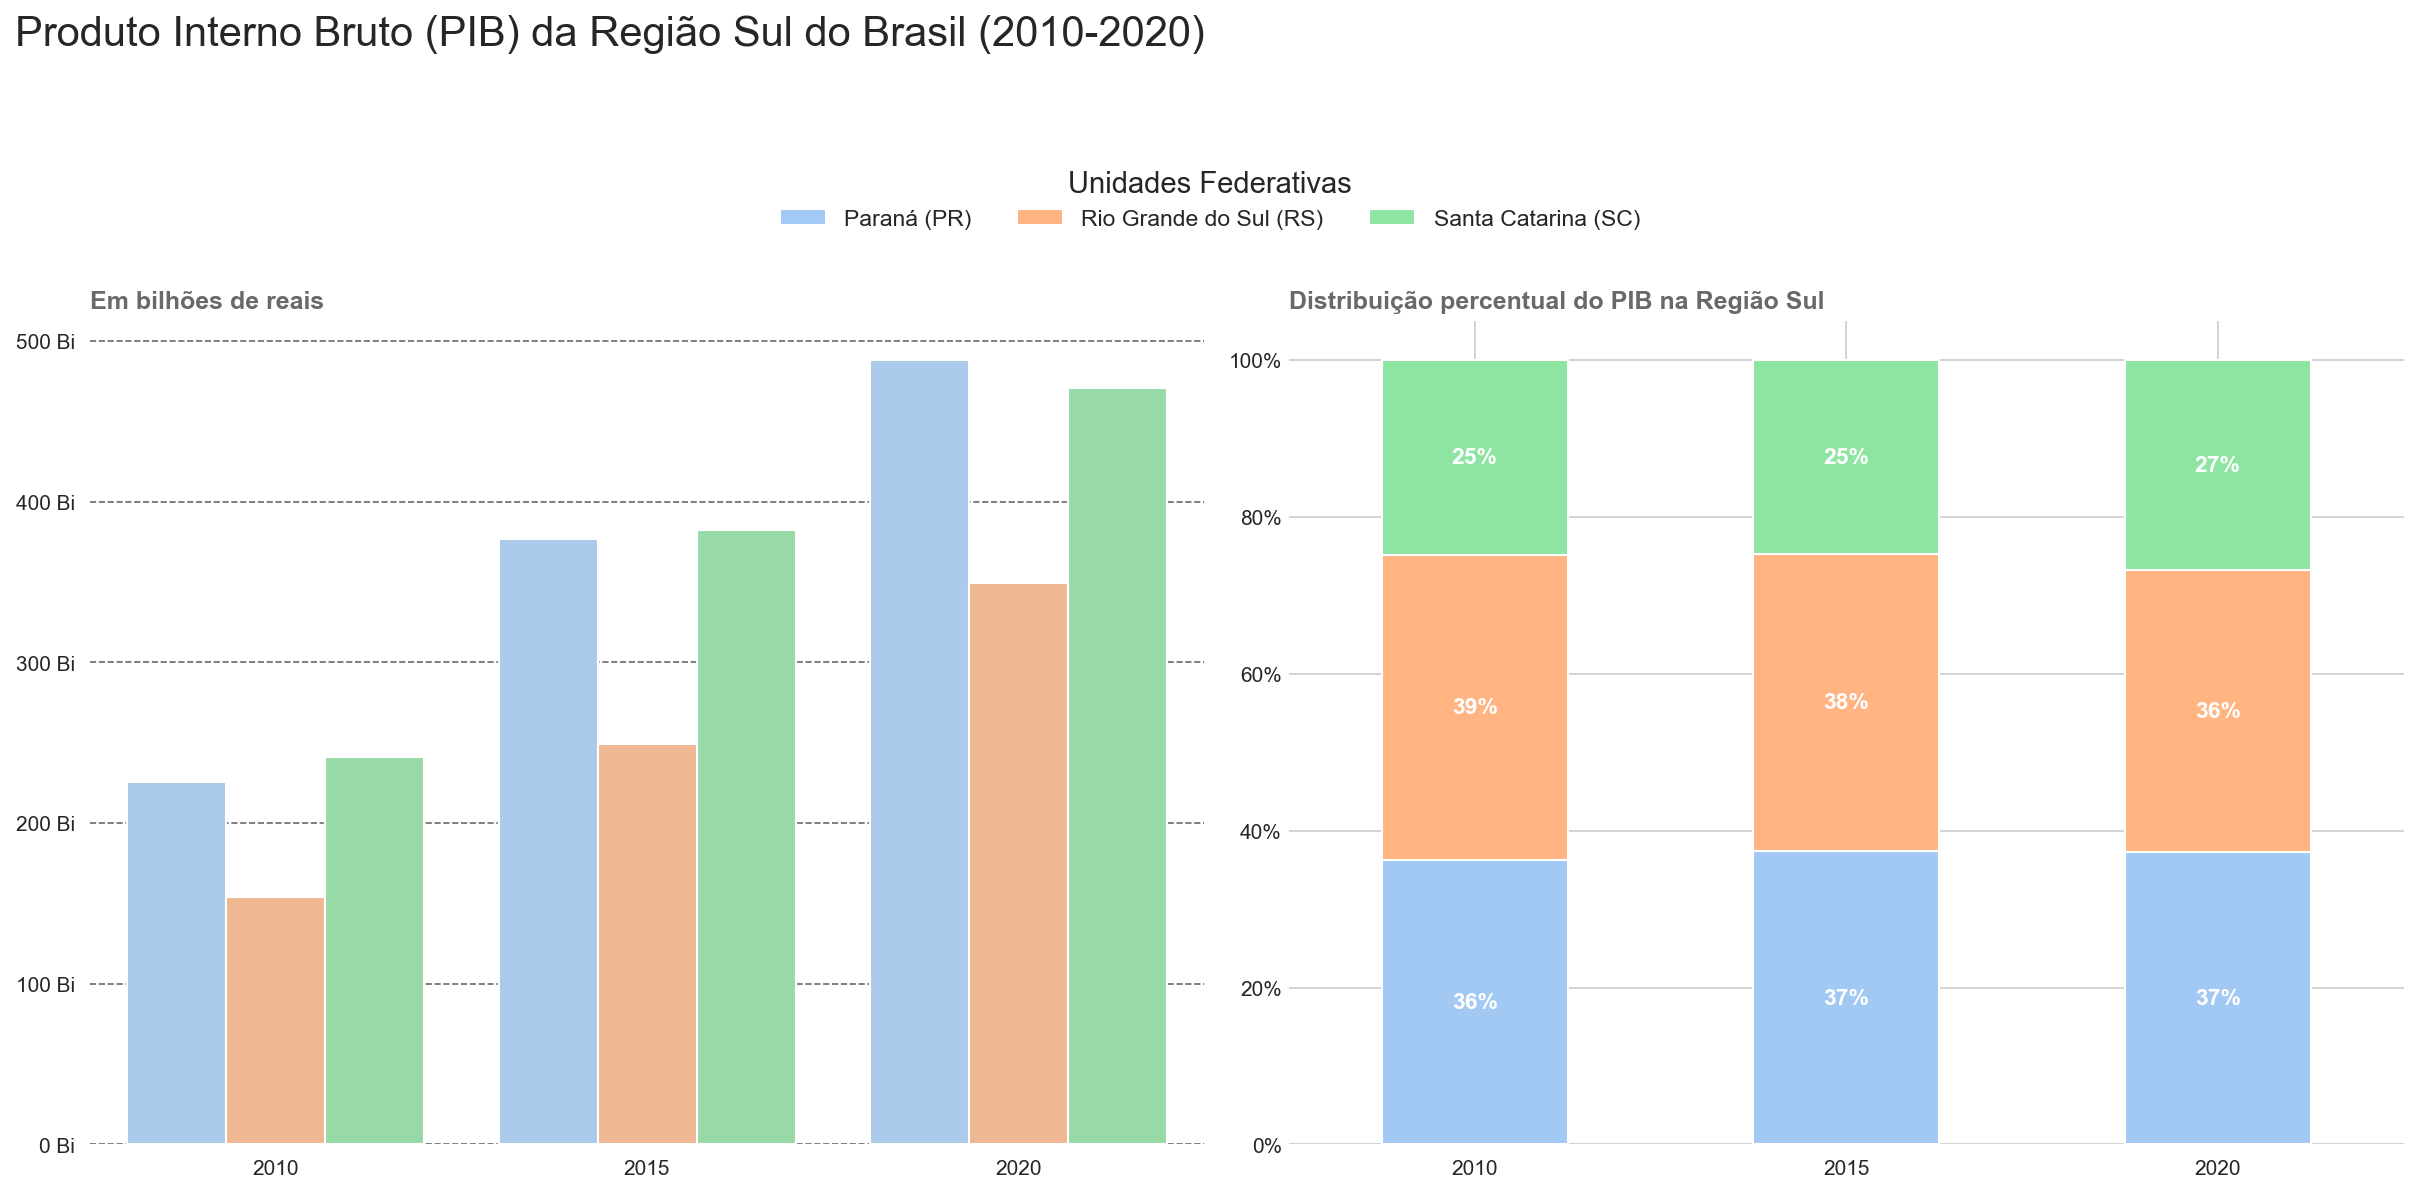

In [ ]:
fig, axs = plt.subplots(figsize=(16, 6), ncols=2, dpi=150, layout="constrained")
fig.suptitle(
    "Produto Interno Bruto (PIB) da Região Sul do Brasil (2010-2020)",
    y=1.3,
    x=0.25,
    size=20,
)
sns.set_palette("pastel")

ax1, ax2 = axs.flatten()
fontdict_title = dict(color="dimgray", weight="bold")
ax1.set_title("Em bilhões de reais", fontdict=fontdict_title, loc="left")
ax1.grid(axis="y", ls="--", color="dimgray", zorder=2)

# Agrupadas (comparação)
sns.barplot(data=df_sul, x="ano", y="pib_bi", hue="sigla_uf", ax=ax1, legend=False)

# Empilhadas em 100% (distribuição/composição)
crosst_sul.plot(x="ano", kind="bar", stacked=True, ax=ax2)
ax2.tick_params(axis="x", rotation=0)
ax2.tick_params(axis="y", length=0)
ax2.set_title(
    "Distribuição percentual do PIB na Região Sul", fontdict=fontdict_title, loc="left"
)


# Formatação dos eixos Y
to_Bi = plt.FuncFormatter(lambda x, _: f"{x:,.0f} Bi")
to_percent = plt.FuncFormatter(lambda y, _: f"{y:.0%}")
ax1.yaxis.set_major_formatter(to_Bi)
ax2.yaxis.set_major_formatter(to_percent)

for ax in axs:
    sns.despine(ax=ax, left=True, bottom=True)
    ax.set_xlabel("")
    ax.set_ylabel("")
    

for container in ax2.containers:
    labels = [f"{valor.get_height() * 100:.0f}%" for valor in container]
    ax2.bar_label(
        container,
        label_type="center",
        labels=labels,
        size=11,
        color="white",
        fontweight="bold",
    )

# Adicionando legenda entre os gráficos:
handles, labels = ax2.get_legend_handles_labels()
fig.legend(
    title="Unidades Federativas",
    labels=["Paraná (PR)", "Rio Grande do Sul (RS)", "Santa Catarina (SC)"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    handles=handles,
    ncol=3,
    frameon=False,
    fontsize=11,
    title_fontsize=14,
)
ax2.get_legend().remove()
plt.show()